<a href="https://colab.research.google.com/github/Divyaa2601/Predictive-Student-Success-Monitoring-System/blob/main/notebooks/04_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Student Success Monitoring System
## Machine Learning Model Training and Evaluation

### Objective

This notebook develops and evaluates machine learning models for predicting
student academic risk as Low, Medium, or High.

The following classification algorithms are compared:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

The models are evaluated using accuracy, precision, recall, F1-score,
classification reports, and confusion matrices.

Since the primary objective of the system is early identification of
academically at-risk students, particular attention is given to the recall
of the High Risk category in addition to overall model performance.

In [1]:
!pip install -q xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
url = (
    "https://raw.githubusercontent.com/"
    "Divyaa2601/"
    "Predictive-Student-Success-Monitoring-System/"
    "main/data/student_success_dataset.csv"
)

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (2000, 15)


In [4]:
df["internal_change"] = (
    df["internal_2"] - df["internal_1"]
)

In [5]:
features = [
    "semester",
    "previous_gpa",
    "attendance_pct",
    "internal_1",
    "internal_2",
    "assignment_avg",
    "assignment_completion_pct",
    "quiz_avg",
    "study_hours_weekly",
    "class_participation",
    "late_submissions",
    "internal_change"
]

X = df[features]
y = df["risk_level"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2000, 12)
Target: (2000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1600, 12)
Testing: (400, 12)


In [7]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(
    "Training missing values:",
    X_train_imputed.isnull().sum().sum()
)

print(
    "Testing missing values:",
    X_test_imputed.isnull().sum().sum()
)

Training missing values: 0
Testing missing values: 0


In [8]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling completed.")

Scaling completed.


## Model 1 — Logistic Regression

In [9]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_scaled
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [10]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

print("LOGISTIC REGRESSION RESULTS")
print("-" * 40)

print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

LOGISTIC REGRESSION RESULTS
----------------------------------------
Accuracy : 0.7225
Precision: 0.7457
Recall   : 0.7225
F1 Score : 0.7314


In [11]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        labels=["High", "Medium", "Low"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.62      0.72      0.67        60
      Medium       0.47      0.54      0.50       100
         Low       0.89      0.80      0.84       240

    accuracy                           0.72       400
   macro avg       0.66      0.69      0.67       400
weighted avg       0.75      0.72      0.73       400



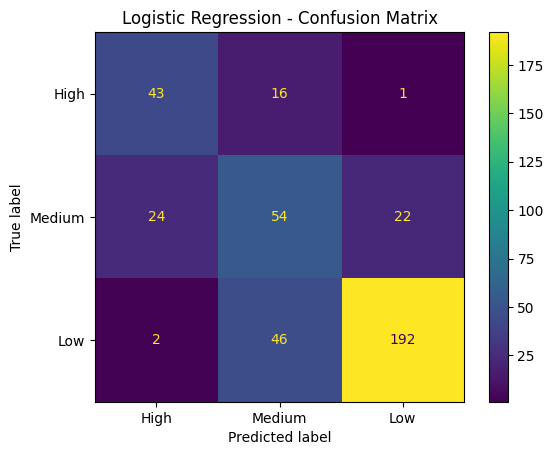

In [12]:
cm = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## Model 2 — Decision Tree

In [13]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5
)

decision_tree_model.fit(
    X_train_imputed,
    y_train
)

decision_tree_predictions = decision_tree_model.predict(
    X_test_imputed
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [14]:
dt_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

dt_precision = precision_score(
    y_test,
    decision_tree_predictions,
    average="weighted",
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    decision_tree_predictions,
    average="weighted",
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    decision_tree_predictions,
    average="weighted",
    zero_division=0
)

print("DECISION TREE RESULTS")
print("-" * 40)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

DECISION TREE RESULTS
----------------------------------------
Accuracy : 0.6925
Precision: 0.7289
Recall   : 0.6925
F1 Score : 0.7056


In [15]:
print(
    classification_report(
        y_test,
        decision_tree_predictions,
        labels=["High", "Medium", "Low"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.44      0.63      0.52        60
      Medium       0.46      0.48      0.47       100
         Low       0.91      0.80      0.85       240

    accuracy                           0.69       400
   macro avg       0.60      0.64      0.61       400
weighted avg       0.73      0.69      0.71       400



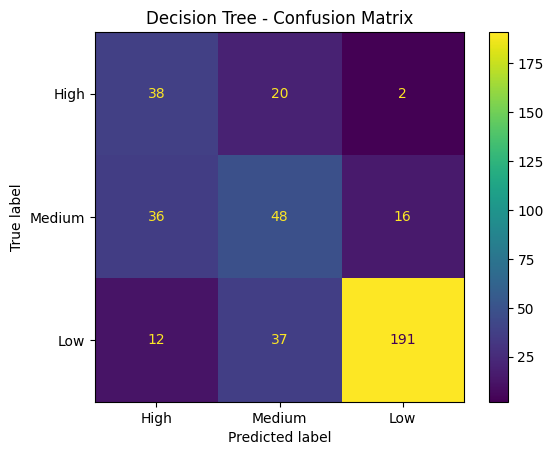

In [16]:
cm = confusion_matrix(
    y_test,
    decision_tree_predictions,
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

## Model 3 — Random Forest

In [17]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_imputed,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test_imputed
)

print("Random Forest training completed.")

Random Forest training completed.


In [18]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

print("RANDOM FOREST RESULTS")
print("-" * 40)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

RANDOM FOREST RESULTS
----------------------------------------
Accuracy : 0.7375
Precision: 0.7479
Recall   : 0.7375
F1 Score : 0.7411


In [19]:
print(
    classification_report(
        y_test,
        rf_predictions,
        labels=["High", "Medium", "Low"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.68      0.57      0.62        60
      Medium       0.49      0.57      0.53       100
         Low       0.87      0.85      0.86       240

    accuracy                           0.74       400
   macro avg       0.68      0.66      0.67       400
weighted avg       0.75      0.74      0.74       400



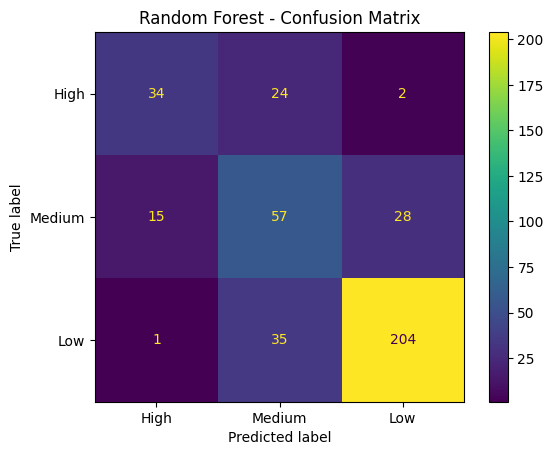

In [20]:
cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

## Model 4 — XGBoost

In [21]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Class mapping:")

for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Class mapping:
High -> 0
Low -> 1
Medium -> 2


In [22]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train_imputed,
    y_train_encoded
)

xgb_predictions_encoded = xgb_model.predict(
    X_test_imputed
)

xgb_predictions = label_encoder.inverse_transform(
    xgb_predictions_encoded
)

print("XGBoost training completed.")

XGBoost training completed.


In [23]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

print("XGBOOST RESULTS")
print("-" * 40)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

XGBOOST RESULTS
----------------------------------------
Accuracy : 0.7425
Precision: 0.7410
Recall   : 0.7425
F1 Score : 0.7404


In [24]:
print(
    classification_report(
        y_test,
        xgb_predictions,
        labels=["High", "Medium", "Low"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.69      0.55      0.61        60
      Medium       0.52      0.54      0.53       100
         Low       0.85      0.88      0.86       240

    accuracy                           0.74       400
   macro avg       0.68      0.66      0.67       400
weighted avg       0.74      0.74      0.74       400



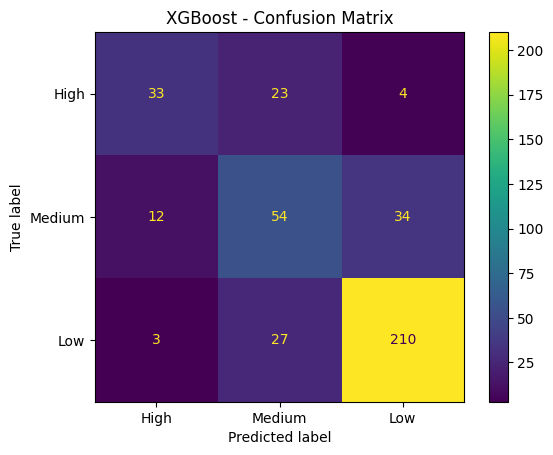

In [25]:
cm = confusion_matrix(
    y_test,
    xgb_predictions,
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot()
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [26]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        logistic_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Weighted Precision": [
        logistic_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],

    "Weighted Recall": [
        logistic_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],

    "Weighted F1": [
        logistic_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ]
})

model_comparison.round(3)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Logistic Regression,0.722,0.746,0.722,0.731
1,Decision Tree,0.692,0.729,0.692,0.706
2,Random Forest,0.738,0.748,0.738,0.741
3,XGBoost,0.742,0.741,0.742,0.740


In [27]:
models_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions
}

high_risk_results = []

for model_name, predictions in models_predictions.items():

    high_precision = precision_score(
        y_test,
        predictions,
        labels=["High"],
        average=None,
        zero_division=0
    )[0]

    high_recall = recall_score(
        y_test,
        predictions,
        labels=["High"],
        average=None,
        zero_division=0
    )[0]

    high_f1 = f1_score(
        y_test,
        predictions,
        labels=["High"],
        average=None,
        zero_division=0
    )[0]

    high_risk_results.append({
        "Model": model_name,
        "High Risk Precision": high_precision,
        "High Risk Recall": high_recall,
        "High Risk F1": high_f1
    })

high_risk_df = pd.DataFrame(high_risk_results)

high_risk_df.round(3)

,Model,High Risk Precision,High Risk Recall,High Risk F1
0,Logistic Regression,0.623,0.717,0.667
1,Decision Tree,0.442,0.633,0.521
2,Random Forest,0.680,0.567,0.618
3,XGBoost,0.688,0.550,0.611


In [28]:
final_comparison = model_comparison.merge(
    high_risk_df,
    on="Model"
)

final_comparison.round(3)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,High Risk Precision,High Risk Recall,High Risk F1
0,Logistic Regression,0.722,0.746,0.722,0.731,0.623,0.717,0.667
1,Decision Tree,0.692,0.729,0.692,0.706,0.442,0.633,0.521
2,Random Forest,0.738,0.748,0.738,0.741,0.680,0.567,0.618
3,XGBoost,0.742,0.741,0.742,0.740,0.688,0.550,0.611


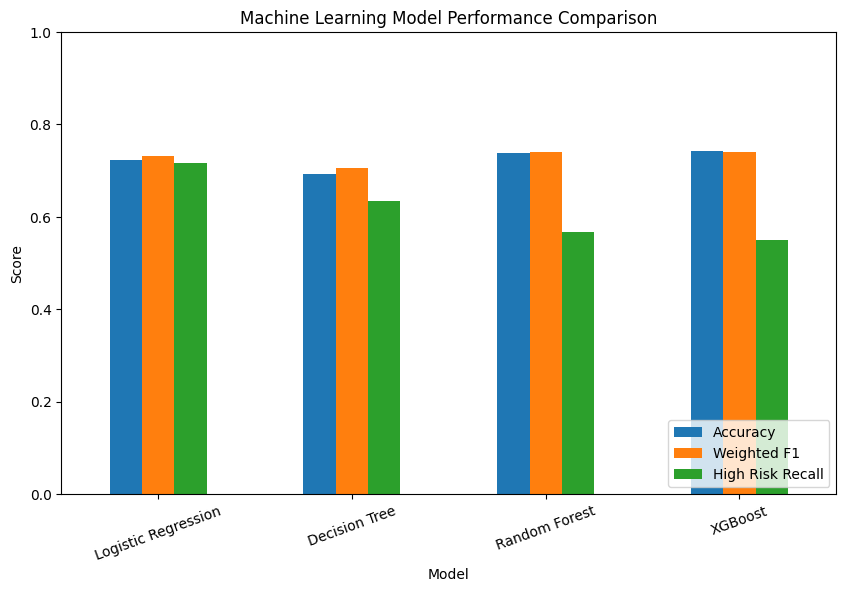

In [29]:
final_comparison.set_index("Model")[
    [
        "Accuracy",
        "Weighted F1",
        "High Risk Recall"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")

plt.show()

## Model Evaluation Summary

Four classification algorithms were evaluated for academic risk prediction:
Logistic Regression, Decision Tree, Random Forest, and XGBoost.

Random Forest and XGBoost achieved the highest overall test accuracy of
approximately 74%, while Logistic Regression achieved approximately 72%.

However, overall accuracy alone is not sufficient for the proposed system.
Since the primary objective is early identification of academically at-risk
students, recall for the High Risk category is particularly important.

Logistic Regression achieved a High Risk recall of approximately 72%,
compared with 63% for Decision Tree, 57% for Random Forest, and 55% for
XGBoost.

Therefore, Logistic Regression provides a useful balance between overall
classification performance and the ability to identify students requiring
academic intervention.

The results also show that the Medium Risk category is more difficult to
classify than clearly Low or High Risk students, reflecting the overlapping
characteristics of borderline academic cases.

Further model tuning and validation will be performed before final deployment.

### Model Tuning

## Model Tuning and Final Model Selection

The initial experiments showed that Random Forest and XGBoost achieved the
highest overall accuracy, while Logistic Regression achieved the highest
recall for the High Risk category.

Since identifying academically at-risk students is a primary objective of
the system, Logistic Regression and Random Forest are selected for further
tuning.

Cross-validation is used to evaluate different hyperparameter combinations
using macro F1-score so that performance across all three risk categories is
considered rather than optimizing only for the majority class.

In [30]:
from sklearn.model_selection import GridSearchCV

print("Model tuning libraries imported.")

Model tuning libraries imported.


In [31]:
logistic_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [
        None,
        "balanced",
        {
            "High": 2.0,
            "Medium": 1.3,
            "Low": 1.0
        },
        {
            "High": 2.5,
            "Medium": 1.5,
            "Low": 1.0
        }
    ]
}

logistic_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_grid=logistic_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

logistic_grid.fit(
    X_train_scaled,
    y_train
)

print("Best Logistic Regression Parameters:")
print(logistic_grid.best_params_)

print(
    "\nBest Cross-Validation Macro F1:",
    round(logistic_grid.best_score_, 4)
)

Best Logistic Regression Parameters:
{'C': 10, 'class_weight': None}

Best Cross-Validation Macro F1: 0.7087


In [32]:
tuned_logistic = logistic_grid.best_estimator_

tuned_logistic_predictions = tuned_logistic.predict(
    X_test_scaled
)

print("TUNED LOGISTIC REGRESSION")
print("-" * 45)

print(
    classification_report(
        y_test,
        tuned_logistic_predictions,
        labels=["High", "Medium", "Low"],
        zero_division=0
    )
)

TUNED LOGISTIC REGRESSION
---------------------------------------------
              precision    recall  f1-score   support

        High       0.72      0.60      0.65        60
      Medium       0.52      0.48      0.50       100
         Low       0.84      0.90      0.87       240

    accuracy                           0.75       400
   macro avg       0.69      0.66      0.67       400
weighted avg       0.74      0.75      0.74       400



In [33]:
rf_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [6, 10, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5],
    "class_weight": [
        None,
        "balanced"
    ]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(
    X_train_imputed,
    y_train
)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print(
    "\nBest Cross-Validation Macro F1:",
    round(rf_grid.best_score_, 4)
)

Best Random Forest Parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}

Best Cross-Validation Macro F1: 0.7191


In [34]:
tuned_rf = rf_grid.best_estimator_

tuned_rf_predictions = tuned_rf.predict(
    X_test_imputed
)

print("TUNED RANDOM FOREST")
print("-" * 45)

print(
    classification_report(
        y_test,
        tuned_rf_predictions,
        labels=["High", "Medium", "Low"],
        zero_division=0
    )
)

TUNED RANDOM FOREST
---------------------------------------------
              precision    recall  f1-score   support

        High       0.66      0.58      0.62        60
      Medium       0.50      0.58      0.54       100
         Low       0.89      0.85      0.87       240

    accuracy                           0.74       400
   macro avg       0.68      0.67      0.68       400
weighted avg       0.76      0.74      0.75       400



In [35]:
def evaluate_model(name, y_true, predictions):

    return {
        "Model": name,

        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Macro F1": f1_score(
            y_true,
            predictions,
            average="macro"
        ),

        "Weighted F1": f1_score(
            y_true,
            predictions,
            average="weighted"
        ),

        "High Risk Precision": precision_score(
            y_true,
            predictions,
            labels=["High"],
            average=None,
            zero_division=0
        )[0],

        "High Risk Recall": recall_score(
            y_true,
            predictions,
            labels=["High"],
            average=None,
            zero_division=0
        )[0],

        "High Risk F1": f1_score(
            y_true,
            predictions,
            labels=["High"],
            average=None,
            zero_division=0
        )[0]
    }


tuned_results = pd.DataFrame([
    evaluate_model(
        "Tuned Logistic Regression",
        y_test,
        tuned_logistic_predictions
    ),

    evaluate_model(
        "Tuned Random Forest",
        y_test,
        tuned_rf_predictions
    )
])

tuned_results.round(3)

,Model,Accuracy,Macro F1,Weighted F1,High Risk Precision,High Risk Recall,High Risk F1
0,Tuned Logistic Regression,0.750,0.674,0.744,0.72,0.600,0.655
1,Tuned Random Forest,0.745,0.676,0.749,0.66,0.583,0.619


## Final Model Selection

Hyperparameter tuning showed that the optimized Logistic Regression model
achieved an overall accuracy of 75%, while the tuned Random Forest achieved
approximately 74.5%.

However, tuning the Logistic Regression model reduced High Risk recall from
72% in the original class-balanced model to 60% in the tuned model.

Since the primary objective of the Predictive Student Success Monitoring
System is to identify students who may require academic intervention, High
Risk recall is considered particularly important.

The original class-balanced Logistic Regression model therefore provides a
more suitable operating point for the current prototype. It identifies a
larger proportion of genuinely High Risk students while maintaining reasonable
overall classification performance.

Accordingly, the class-balanced Logistic Regression model is selected as the
final model for the current prototype.

This selection reflects the intervention-oriented objective of the system
rather than choosing a model solely based on overall accuracy.

In [36]:
final_model = logistic_model

final_predictions = final_model.predict(
    X_test_scaled
)

print("FINAL MODEL: Logistic Regression (Class Balanced)")
print("-" * 55)

print(
    classification_report(
        y_test,
        final_predictions,
        labels=["High", "Medium", "Low"],
        zero_division=0
    )
)

FINAL MODEL: Logistic Regression (Class Balanced)
-------------------------------------------------------
              precision    recall  f1-score   support

        High       0.62      0.72      0.67        60
      Medium       0.47      0.54      0.50       100
         Low       0.89      0.80      0.84       240

    accuracy                           0.72       400
   macro avg       0.66      0.69      0.67       400
weighted avg       0.75      0.72      0.73       400



In [37]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    final_model,
    "models/student_risk_model.pkl"
)

joblib.dump(
    imputer,
    "models/imputer.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

joblib.dump(
    features,
    "models/feature_names.pkl"
)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.
